# Deepert Petrophysical Transform Benchmark

这个 notebook 用来比较 Deepert 时移 ERT 反演中的三种参数化：

- `log_resistivity`: 旧版默认，直接反演电阻率的对数。
- `log_conductivity`: 反演电导率的对数，再映射到电阻率正演。
- `saturation`: 反演饱和度，通过岩石物理关系映射到电阻率正演，并额外输出含水率 `theta = phi * S`。

默认是快测模式：`MAX_TIMESTEPS = 30`, `MAX_ITERATIONS = 6`。确认稳定后可以把 `MAX_TIMESTEPS = None` 跑全年。


In [1]:
from __future__ import annotations

import json
import subprocess
import sys
import time
from pathlib import Path

cwd = Path.cwd().resolve()
ROOT = cwd.parent if cwd.name == 'examples' else cwd
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import LogNorm, Normalize
from matplotlib.tri import Triangulation

from deepert.inversion import build_petrophysical_transform

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans']
plt.rcParams['axes.labelsize'] = 13
plt.rcParams['xtick.labelsize'] = 11
plt.rcParams['ytick.labelsize'] = 11
plt.rcParams['legend.fontsize'] = 11

SCRIPT = ROOT / 'examples' / '2_timelapsedERT_inversion_deepert.py'
FORWARD_DIR = ROOT / 'result' / '1_timelapsedERT_forward_deepert'
TRUE_MODEL_DIR = ROOT / 'resistivity_models_2d'
PETRO_DIR = ROOT / 'parflow_models' / 'petrophysical_models_2d'
BENCH_ROOT = ROOT / 'result' / '4_petrophysical_transform_benchmark_deepert'
BENCH_ROOT.mkdir(parents=True, exist_ok=True)

print('ROOT =', ROOT)
print('SCRIPT =', SCRIPT)
print('BENCH_ROOT =', BENCH_ROOT)


ROOT = /home/luffy/deepertv1
SCRIPT = /home/luffy/deepertv1/examples/2_timelapsedERT_inversion_deepert.py
BENCH_ROOT = /home/luffy/deepertv1/result/4_petrophysical_transform_benchmark_deepert


## Run Settings

如果只是先看趋势，保持默认即可。准备跑论文级结果时，把 `MAX_TIMESTEPS` 改成 `None`，并适当增大 `MAX_ITERATIONS`。


In [2]:
MAX_TIMESTEPS = 30        # None means all timesteps.
MAX_ITERATIONS = 6        # Production default can be 15 or higher.
CGLS_MAX_ITERATIONS = 40  # Production default can be 60 or higher.
WINDOW_SIZE = 3
WINDOW_STEP = 1
FILE_STRIDE = 1
FORCE_RERUN = False

OPTIMIZER = 'gauss_newton_cgls'
LINEARIZED_SOLVER = 'gpu_cgls'

Y_INDEX = 2
PETRO_PRESET = 'table1_mean'
SATURATION_FLOOR = 1.0e-4

COMMON_ARGS = [
    '--forward-dir', str(FORWARD_DIR),
    '--true-model-dir', str(TRUE_MODEL_DIR),
    '--inversion-mode', 'windowed',
    '--window-size', str(WINDOW_SIZE),
    '--window-step', str(WINDOW_STEP),
    '--file-stride', str(FILE_STRIDE),
    '--max-iterations', str(MAX_ITERATIONS),
    '--cgls-max-iterations', str(CGLS_MAX_ITERATIONS),
    '--optimizer', OPTIMIZER,
    '--linearized-solver', LINEARIZED_SOLVER,
    '--y-index', str(Y_INDEX),
    '--petrophysical-parameter-dir', str(PETRO_DIR),
    '--petrophysical-preset', PETRO_PRESET,
    '--saturation-floor', str(SATURATION_FLOOR),
    '--no-plot',
    '--quiet',
]
if MAX_TIMESTEPS is not None:
    COMMON_ARGS += ['--max-timesteps', str(MAX_TIMESTEPS)]

TRANSFORM_CASES = [
    {
        'name': 'log_resistivity',
        'label': 'Log resistivity',
        'args': ['--petrophysical-transform', 'log_resistivity'],
    },
    {
        'name': 'log_conductivity',
        'label': 'Log conductivity',
        'args': ['--petrophysical-transform', 'log_conductivity'],
    },
    {
        'name': 'saturation',
        'label': 'Saturation',
        'args': ['--petrophysical-transform', 'saturation'],
    },
]

print('Common args:')
print(' '.join(COMMON_ARGS))


Common args:
--forward-dir /home/luffy/deepertv1/result/1_timelapsedERT_forward_deepert --true-model-dir /home/luffy/deepertv1/resistivity_models_2d --inversion-mode windowed --window-size 3 --window-step 1 --file-stride 1 --max-iterations 6 --cgls-max-iterations 40 --optimizer gauss_newton_cgls --linearized-solver gpu_cgls --y-index 2 --petrophysical-parameter-dir /home/luffy/deepertv1/parflow_models/petrophysical_models_2d --petrophysical-preset table1_mean --saturation-floor 0.0001 --no-plot --quiet --max-timesteps 30


## Run Or Load Cases

每个 case 会写到 `result/4_petrophysical_transform_benchmark_deepert/<case_name>`。如果已有 summary 且参数匹配，默认读取缓存；要强制重跑设 `FORCE_RERUN = True`。


In [3]:
def _expected_arg(case: dict, option: str, default=None):
    args = case.get('args', [])
    for idx, value in enumerate(args[:-1]):
        if value == option:
            return args[idx + 1]
    return default


def _cache_matches_case(summary: dict, case: dict) -> bool:
    expected = {
        'petrophysical_transform': _expected_arg(case, '--petrophysical-transform'),
        'optimizer': OPTIMIZER,
        'linearized_solver': LINEARIZED_SOLVER,
        'n_timesteps': MAX_TIMESTEPS,
    }
    for key, expected_value in expected.items():
        if expected_value is None:
            continue
        if summary.get(key) != expected_value:
            return False
    return True


def run_case(case: dict) -> dict:
    out_dir = BENCH_ROOT / case['name']
    summary_file = out_dir / 'timelapsed_inversion_summary.json'
    log_file = out_dir / 'run.log'
    out_dir.mkdir(parents=True, exist_ok=True)

    if summary_file.exists() and not FORCE_RERUN:
        summary = json.loads(summary_file.read_text(encoding='utf-8'))
        if _cache_matches_case(summary, case):
            summary['case_name'] = case['name']
            summary['case_label'] = case['label']
            summary['status'] = 'cached'
            return summary
        print(f"Cache mismatch for {case['name']}; rerunning.")

    cmd = [
        'uv', 'run', 'python', str(SCRIPT),
        '--output-dir', str(out_dir),
        *COMMON_ARGS,
        *case['args'],
    ]
    print('\nRunning:', case['name'])
    print(' '.join(cmd))
    t0 = time.perf_counter()
    proc = subprocess.run(cmd, cwd=ROOT, text=True, capture_output=True)
    elapsed = time.perf_counter() - t0
    log_file.write_text(
        'COMMAND:\n' + ' '.join(cmd) + '\n\nSTDOUT:\n' + proc.stdout + '\n\nSTDERR:\n' + proc.stderr,
        encoding='utf-8',
    )
    if proc.returncode != 0:
        raise RuntimeError(f"Case {case['name']} failed with code {proc.returncode}. See {log_file}")
    if not summary_file.exists():
        raise FileNotFoundError(f'Expected summary was not created: {summary_file}')

    summary = json.loads(summary_file.read_text(encoding='utf-8'))
    summary['case_name'] = case['name']
    summary['case_label'] = case['label']
    summary['status'] = 'ran'
    summary['notebook_elapsed_sec'] = elapsed
    return summary

summaries = [run_case(case) for case in TRANSFORM_CASES]
print(f'Finished {len(summaries)} cases.')



Running: log_resistivity
uv run python /home/luffy/deepertv1/examples/2_timelapsedERT_inversion_deepert.py --output-dir /home/luffy/deepertv1/result/4_petrophysical_transform_benchmark_deepert/log_resistivity --forward-dir /home/luffy/deepertv1/result/1_timelapsedERT_forward_deepert --true-model-dir /home/luffy/deepertv1/resistivity_models_2d --inversion-mode windowed --window-size 3 --window-step 1 --file-stride 1 --max-iterations 6 --cgls-max-iterations 40 --optimizer gauss_newton_cgls --linearized-solver gpu_cgls --y-index 2 --petrophysical-parameter-dir /home/luffy/deepertv1/parflow_models/petrophysical_models_2d --petrophysical-preset table1_mean --saturation-floor 0.0001 --no-plot --quiet --max-timesteps 30 --petrophysical-transform log_resistivity

Running: log_conductivity
uv run python /home/luffy/deepertv1/examples/2_timelapsedERT_inversion_deepert.py --output-dir /home/luffy/deepertv1/result/4_petrophysical_transform_benchmark_deepert/log_conductivity --forward-dir /home/lu

## Summary Table

重点先看 `final_chi2`, `elapsed_min`, `saved_parameter_models`, `saved_water_content_models`。


In [4]:
summary_rows = []
for summary in summaries:
    out_dir = BENCH_ROOT / summary['case_name']
    chi2_path = out_dir / 'chi2_all.npy'
    chi2 = np.load(chi2_path) if chi2_path.exists() else np.asarray([])
    summary_rows.append({
        'case': summary['case_name'],
        'label': summary['case_label'],
        'status': summary.get('status'),
        'transform': summary.get('petrophysical_transform'),
        'parameter': summary.get('petrophysical_parameter'),
        'n_timesteps': summary.get('n_timesteps'),
        'n_windows': summary.get('n_windows'),
        'elapsed_min': summary.get('elapsed_min'),
        'final_chi2': float(chi2[-1]) if chi2.size else np.nan,
        'mean_chi2': float(np.nanmean(chi2)) if chi2.size else np.nan,
        'saved_parameter_models': summary.get('saved_parameter_models'),
        'saved_water_content_models': summary.get('saved_water_content_models'),
        'out_dir': str(out_dir),
    })

summary_df = pd.DataFrame(summary_rows)
summary_df


,case,label,status,transform,parameter,n_timesteps,n_windows,elapsed_min,final_chi2,mean_chi2,saved_parameter_models,saved_water_content_models,out_dir
0,log_resistivity,Log resistivity,ran,log_resistivity,resistivity,30,28,0.711872,3.061587,2.986395,False,False,/home/luffy/deepertv1/result/4_petrophysical_t...
1,log_conductivity,Log conductivity,ran,log_conductivity,conductivity,30,28,0.701828,3.061587,2.986395,True,False,/home/luffy/deepertv1/result/4_petrophysical_t...
2,saturation,Saturation,ran,saturation,saturation,30,28,0.991230,6.892716,6.858813,True,True,/home/luffy/deepertv1/result/4_petrophysical_t...


## Convergence And Runtime

`chi2` 是每个滑窗最终的 data chi2。这里先看不同参数化是否都能稳定下降，以及是否有明显速度代价。


findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family ['Arial'] not found. Falling back to DejaVu Sans.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Ari

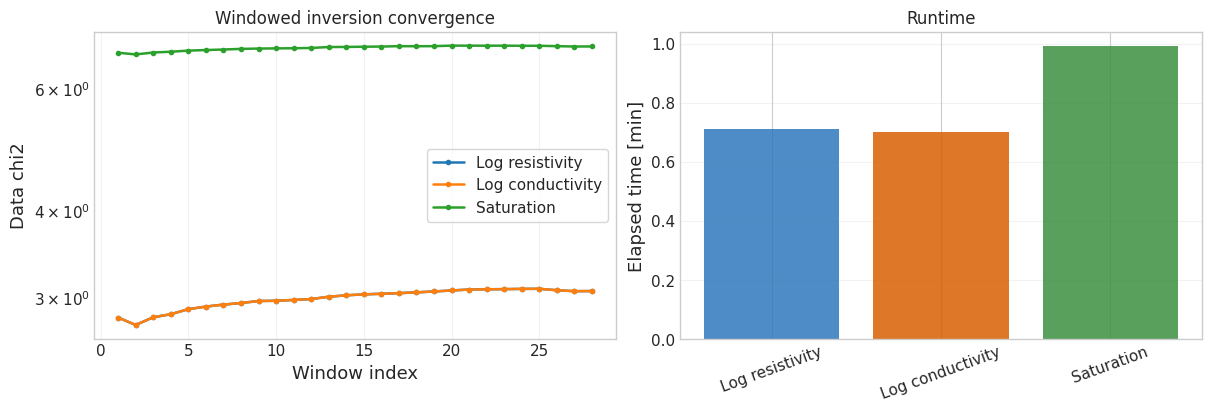

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)

for row in summary_rows:
    chi2 = np.load(Path(row['out_dir']) / 'chi2_all.npy')
    axes[0].plot(np.arange(1, chi2.size + 1), chi2, marker='o', ms=3, lw=1.8, label=row['label'])
axes[0].set_yscale('log')
axes[0].set_xlabel('Window index')
axes[0].set_ylabel('Data chi2')
axes[0].set_title('Windowed inversion convergence')
axes[0].legend(frameon=True)
axes[0].grid(alpha=0.25)

axes[1].bar(summary_df['label'], summary_df['elapsed_min'], color=['#2f78bd', '#d95f02', '#3b8f3f'], alpha=0.85)
axes[1].set_ylabel('Elapsed time [min]')
axes[1].set_title('Runtime')
axes[1].tick_params(axis='x', rotation=20)
axes[1].grid(axis='y', alpha=0.25)
plt.show()


## Load Models And Petrophysical Parameters

这里把所有结果统一转成三个量：

- `rho`: 电阻率模型。
- `saturation`: 饱和度模型。对于 `log_resistivity` 和 `log_conductivity`，这里用同一套岩石物理参数反算得到。
- `water_content`: 含水率模型，`theta = phi * saturation`。


In [6]:
def _load_geometry(path: Path) -> dict[str, np.ndarray]:
    with np.load(path) as data:
        return {name: np.asarray(data[name], dtype=float).ravel() for name in ('x_nodes', 'z_top', 'layer_thickness')}


def _mesh_cell_centers(nodes: np.ndarray, cells: np.ndarray) -> np.ndarray:
    return np.asarray(nodes, dtype=float)[np.asarray(cells, dtype=np.int32)].mean(axis=1)


def _grid2d_to_mesh_cells(values_2d: np.ndarray, nodes: np.ndarray, cells: np.ndarray, geometry: dict[str, np.ndarray]) -> np.ndarray:
    grid = np.asarray(values_2d)
    x_nodes = np.asarray(geometry['x_nodes'], dtype=float).ravel()
    z_top = np.asarray(geometry['z_top'], dtype=float).ravel()
    layer_thickness = np.asarray(geometry['layer_thickness'], dtype=float).ravel()
    expected_shape = (layer_thickness.size, x_nodes.size - 1)
    if grid.shape != expected_shape:
        raise ValueError(f'2D grid shape {grid.shape} does not match expected {expected_shape}')

    centers = _mesh_cell_centers(nodes, cells)
    x_center = centers[:, 0]
    z_center = centers[:, 1]
    column = np.searchsorted(x_nodes, x_center, side='right') - 1
    column = np.clip(column, 0, x_nodes.size - 2)
    surface_z = np.interp(x_center, x_nodes, z_top)
    depth = np.maximum(surface_z - z_center, 0.0)
    layer_top_to_bottom = np.searchsorted(np.cumsum(layer_thickness), depth, side='right')
    layer_top_to_bottom = np.clip(layer_top_to_bottom, 0, layer_thickness.size - 1)
    return np.asarray(grid[::-1, :][layer_top_to_bottom, column])


def _load_mesh(out_dir: Path) -> tuple[np.ndarray, np.ndarray]:
    with np.load(out_dir / 'timelapse_inversion_mesh.npz') as data:
        return np.asarray(data['nodes'], dtype=float), np.asarray(data['cells'], dtype=np.int32)


def _load_petro_on_mesh(out_dir: Path) -> dict[str, np.ndarray]:
    nodes, cells = _load_mesh(out_dir)
    geometry = _load_geometry(FORWARD_DIR / 'forward_geometry.npz')
    files = {
        'rho_sat': PETRO_DIR / f'rho_sat2d_y{Y_INDEX}_base_{PETRO_PRESET}.npy',
        'rho_sat_s': PETRO_DIR / f'rho_sat_s2d_y{Y_INDEX}_base_{PETRO_PRESET}.npy',
        'n': PETRO_DIR / f'n2d_y{Y_INDEX}_base_{PETRO_PRESET}.npy',
        'phi': PETRO_DIR / f'phi2d_y{Y_INDEX}_base_{PETRO_PRESET}.npy',
        'class': PETRO_DIR / f'class2d_y{Y_INDEX}.npy',
    }
    mapped = {}
    for name, path in files.items():
        if path.exists():
            mapped[name] = np.asarray(_grid2d_to_mesh_cells(np.load(path), nodes, cells, geometry), dtype=float)
    return mapped


def _saturation_from_logrho(log_rho: np.ndarray, petro: dict[str, np.ndarray]) -> np.ndarray:
    transform = build_petrophysical_transform(
        'saturation',
        n_cells=log_rho.shape[0],
        saturation_floor=SATURATION_FLOOR,
        parameters={
            'rho_sat': petro['rho_sat'],
            'rho_sat_s': petro.get('rho_sat_s'),
            'n': petro['n'],
        },
    )
    state = transform.state_from_log_resistivity(log_rho)
    return transform.parameter_from_state(state)


def load_case_models(row: dict) -> dict:
    out_dir = Path(row['out_dir'])
    nodes, cells = _load_mesh(out_dir)
    petro = _load_petro_on_mesh(out_dir)
    steps = np.load(out_dir / 'steps.npy')
    rho = np.asarray(np.load(out_dir / 'final_models.npy'), dtype=float)
    log_rho = np.asarray(np.load(out_dir / 'final_log_models.npy'), dtype=float)
    sat_file = out_dir / 'final_saturation_models.npy'
    if sat_file.exists():
        saturation = np.asarray(np.load(sat_file), dtype=float)
    else:
        saturation = _saturation_from_logrho(log_rho, petro)
    water_content = saturation * petro['phi'][:, None] if 'phi' in petro else np.full_like(saturation, np.nan)
    return {
        'out_dir': out_dir,
        'nodes': nodes,
        'cells': cells,
        'steps': steps,
        'rho': rho,
        'log_rho': log_rho,
        'saturation': saturation,
        'water_content': water_content,
        'petro': petro,
    }

case_models = {row['case']: load_case_models(row) for row in summary_rows}
print({name: data['rho'].shape for name, data in case_models.items()})


{'log_resistivity': (911, 30), 'log_conductivity': (911, 30), 'saturation': (911, 30)}


## Representative Time Selection

如果是全年结果，默认使用 Day 1, 190, 294, 365。快测结果时间不够时，会自动选择最接近的可用时间并去重。


In [7]:
PLOT_DAYS = [1, 190, 294, 365]
reference_steps = next(iter(case_models.values()))['steps']
reference_days = reference_steps.astype(float) / 24.0 + 1.0

selected_indices = []
for day in PLOT_DAYS:
    selected_indices.append(int(np.argmin(np.abs(reference_days - day))))
selected_indices = list(dict.fromkeys(selected_indices))
if len(selected_indices) < min(len(PLOT_DAYS), reference_days.size):
    # In short smoke runs several requested days map to the same last timestep.
    fallback = np.linspace(0, reference_days.size - 1, min(4, reference_days.size), dtype=int).tolist()
    selected_indices = list(dict.fromkeys(fallback + selected_indices))[:min(4, reference_days.size)]

selected_table = pd.DataFrame({
    'index': selected_indices,
    'step': reference_steps[selected_indices],
    'day': reference_days[selected_indices],
})
selected_table


,index,step,day
0,0,0,1.0
1,9,216,10.0
2,19,456,20.0
3,29,696,30.0


## Spatial Maps

下面分别画电阻率、饱和度和含水率。默认用所有 case 的共同色标，便于直接横向比较。


findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

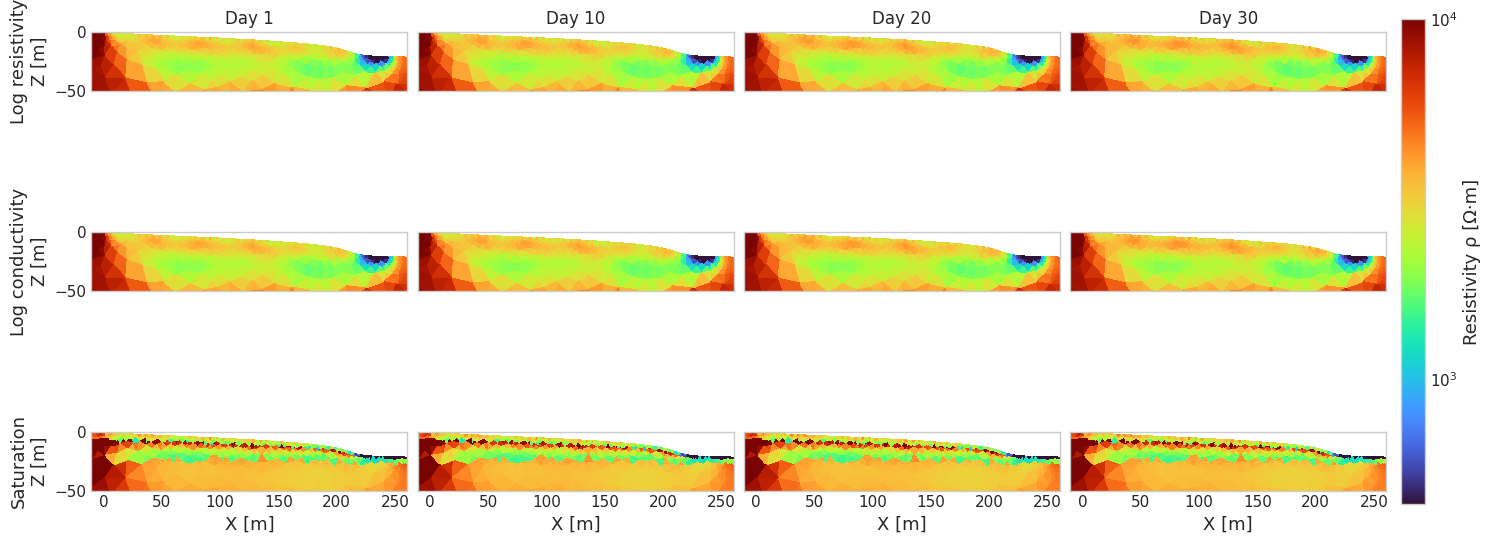

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

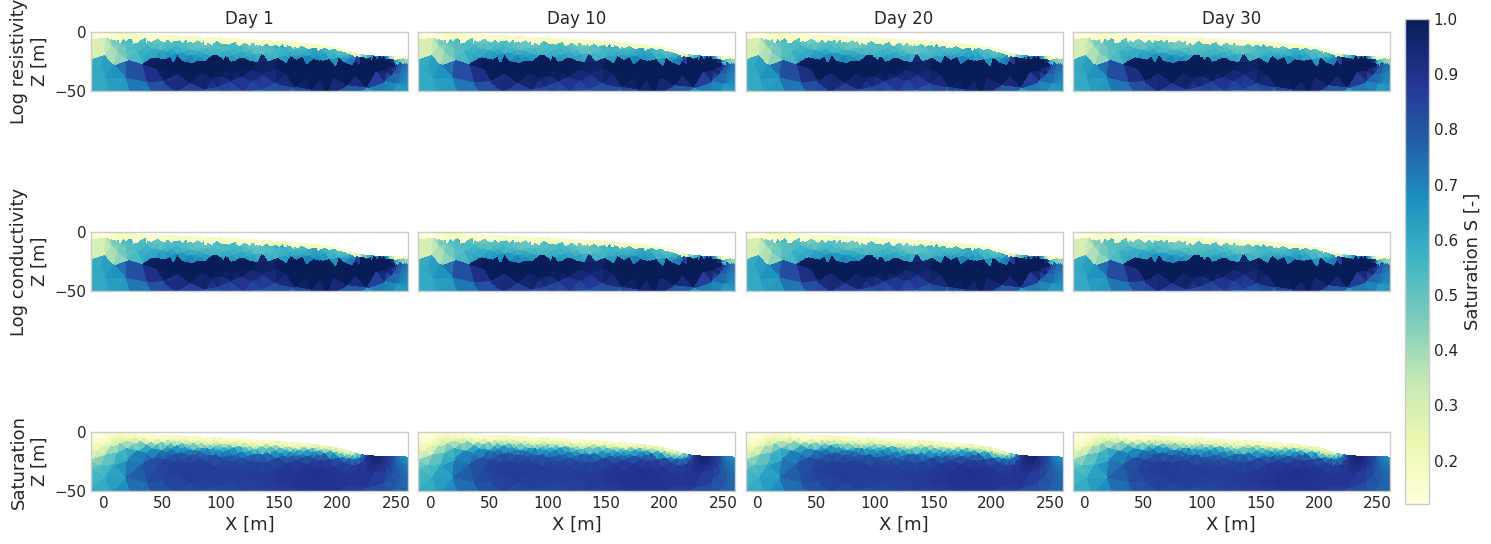

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

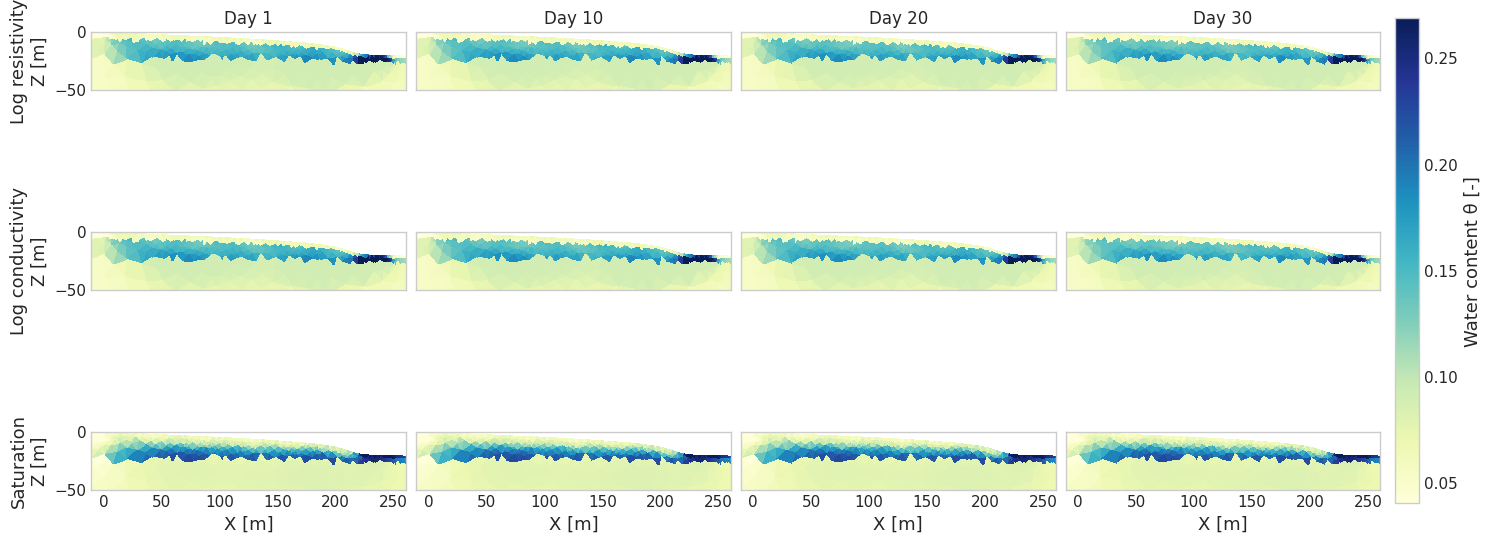

In [8]:
def _common_limits(variable: str, log_scale: bool = False) -> tuple[float, float]:
    values = []
    for data in case_models.values():
        arr = np.asarray(data[variable], dtype=float)[:, selected_indices]
        values.append(arr[np.isfinite(arr)])
    merged = np.concatenate([v.reshape(-1) for v in values if v.size])
    if log_scale:
        merged = merged[merged > 0]
    vmin = float(np.nanpercentile(merged, 2))
    vmax = float(np.nanpercentile(merged, 98))
    if vmin == vmax:
        vmax = vmin * 1.01 if vmin != 0 else 1.0
    return vmin, vmax


def plot_model_grid(variable: str, label: str, *, cmap: str = 'viridis', log_scale: bool = False) -> None:
    vmin, vmax = _common_limits(variable, log_scale=log_scale)
    norm = LogNorm(vmin=max(vmin, np.finfo(float).tiny), vmax=vmax) if log_scale else Normalize(vmin=vmin, vmax=vmax)
    nrows = len(summary_rows)
    ncols = len(selected_indices)
    fig, axes = plt.subplots(nrows, ncols, figsize=(3.7 * ncols, 2.0 * nrows), constrained_layout=True, squeeze=False)
    last = None
    for row_idx, row in enumerate(summary_rows):
        data = case_models[row['case']]
        tri = Triangulation(data['nodes'][:, 0], data['nodes'][:, 1], data['cells'])
        for col_idx, time_index in enumerate(selected_indices):
            ax = axes[row_idx, col_idx]
            values = np.asarray(data[variable], dtype=float)[:, time_index]
            last = ax.tripcolor(tri, facecolors=values, shading='flat', cmap=cmap, norm=norm)
            ax.set_aspect('equal', adjustable='box')
            ax.set_xlim(np.nanmin(data['nodes'][:, 0]), np.nanmax(data['nodes'][:, 0]))
            ax.set_ylim(-50, 0)
            ax.grid(False)
            if row_idx == 0:
                ax.set_title(f"Day {reference_days[time_index]:.0f}")
            if col_idx == 0:
                ax.set_ylabel(row['label'] + '\nZ [m]')
            else:
                ax.tick_params(labelleft=False)
            if row_idx == nrows - 1:
                ax.set_xlabel('X [m]')
            else:
                ax.tick_params(labelbottom=False)
    cbar = fig.colorbar(last, ax=axes, shrink=0.82, pad=0.01)
    cbar.set_label(label)
    plt.show()

plot_model_grid('rho', 'Resistivity ρ [Ω·m]', cmap='turbo', log_scale=True)
plot_model_grid('saturation', 'Saturation S [-]', cmap='YlGnBu', log_scale=False)
plot_model_grid('water_content', 'Water content θ [-]', cmap='YlGnBu', log_scale=False)


## Difference Against Log-Resistivity Baseline

这里把 `log_conductivity` 和 `saturation` 与默认 `log_resistivity` 做差，主要看参数化是否改变空间结构和事件响应。


findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

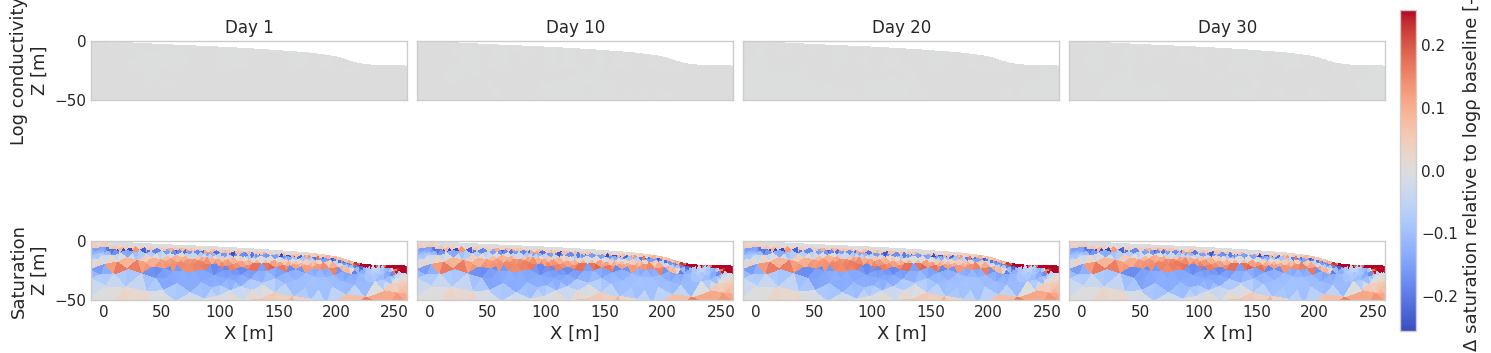

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

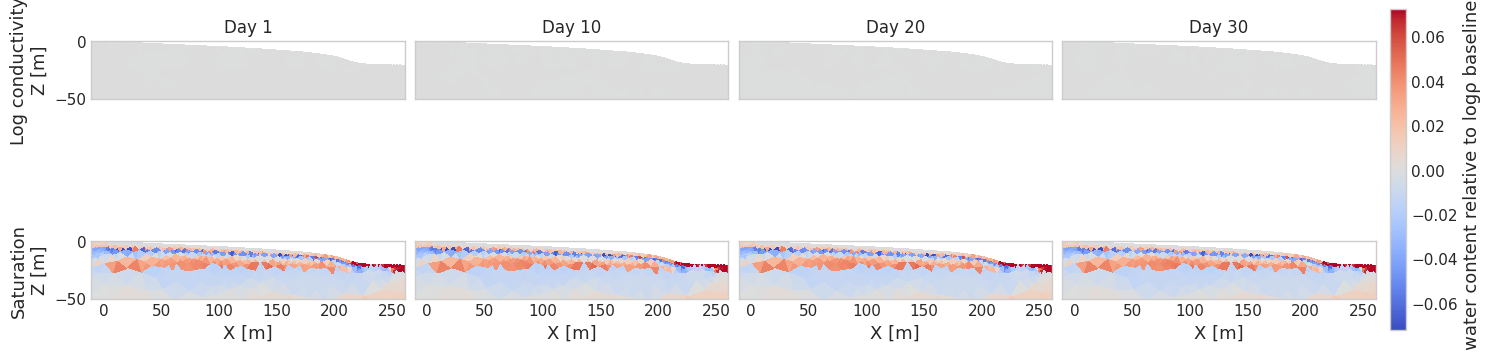

In [9]:
def plot_difference_to_baseline(variable: str, label: str, *, cmap: str = 'coolwarm') -> None:
    baseline_key = 'log_resistivity'
    if baseline_key not in case_models:
        print('No log_resistivity baseline found.')
        return
    compare_rows = [row for row in summary_rows if row['case'] != baseline_key]
    if not compare_rows:
        print('No comparison cases.')
        return
    baseline = case_models[baseline_key]
    diffs = []
    for row in compare_rows:
        diffs.append(np.asarray(case_models[row['case']][variable], dtype=float)[:, selected_indices] - np.asarray(baseline[variable], dtype=float)[:, selected_indices])
    merged = np.concatenate([d[np.isfinite(d)] for d in diffs if np.any(np.isfinite(d))])
    lim = float(np.nanpercentile(np.abs(merged), 98)) if merged.size else 1.0
    lim = max(lim, 1.0e-8)

    nrows = len(compare_rows)
    ncols = len(selected_indices)
    fig, axes = plt.subplots(nrows, ncols, figsize=(3.7 * ncols, 2.0 * nrows), constrained_layout=True, squeeze=False)
    last = None
    for row_idx, (row, diff) in enumerate(zip(compare_rows, diffs)):
        data = case_models[row['case']]
        tri = Triangulation(data['nodes'][:, 0], data['nodes'][:, 1], data['cells'])
        for col_idx, time_index in enumerate(selected_indices):
            ax = axes[row_idx, col_idx]
            last = ax.tripcolor(tri, facecolors=diff[:, col_idx], shading='flat', cmap=cmap, vmin=-lim, vmax=lim)
            ax.set_aspect('equal', adjustable='box')
            ax.set_xlim(np.nanmin(data['nodes'][:, 0]), np.nanmax(data['nodes'][:, 0]))
            ax.set_ylim(-50, 0)
            ax.grid(False)
            if row_idx == 0:
                ax.set_title(f"Day {reference_days[time_index]:.0f}")
            if col_idx == 0:
                ax.set_ylabel(row['label'] + '\nZ [m]')
            else:
                ax.tick_params(labelleft=False)
            if row_idx == nrows - 1:
                ax.set_xlabel('X [m]')
            else:
                ax.tick_params(labelbottom=False)
    cbar = fig.colorbar(last, ax=axes, shrink=0.82, pad=0.01)
    cbar.set_label(label)
    plt.show()

plot_difference_to_baseline('saturation', 'Δ saturation relative to logρ baseline [-]')
plot_difference_to_baseline('water_content', 'Δ water content relative to logρ baseline [-]')


## Mean Time Series

先看整个反演域的平均饱和度和平均含水率。这个图对于判断趋势是否跟降雨/蒸散事件一致很有用。


findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

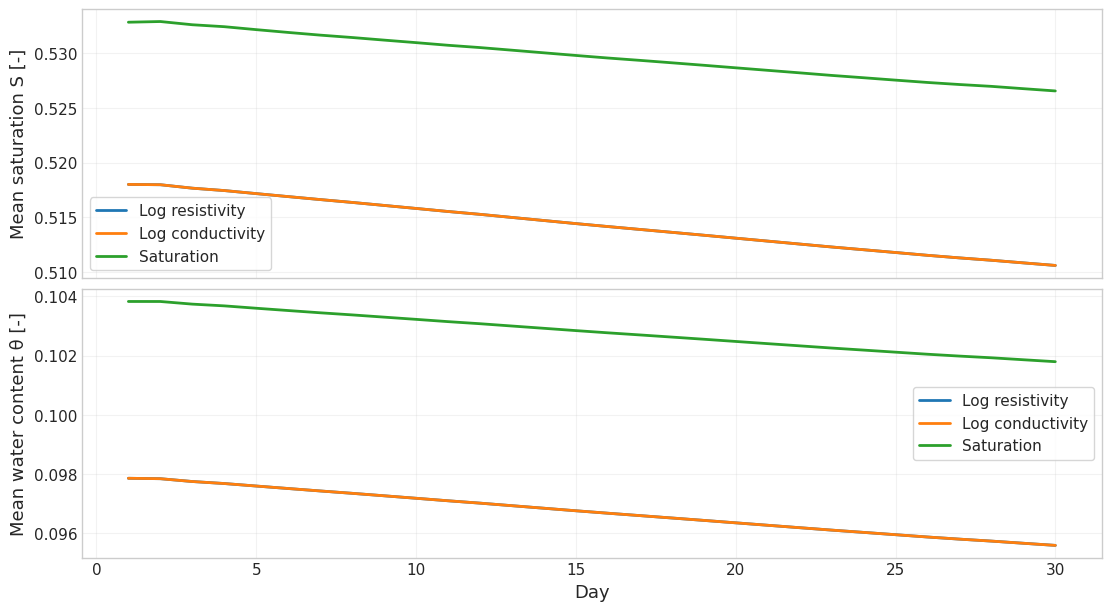

In [10]:
fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True, constrained_layout=True)
for row in summary_rows:
    data = case_models[row['case']]
    days = data['steps'].astype(float) / 24.0 + 1.0
    axes[0].plot(days, np.nanmean(data['saturation'], axis=0), lw=2.0, label=row['label'])
    axes[1].plot(days, np.nanmean(data['water_content'], axis=0), lw=2.0, label=row['label'])
axes[0].set_ylabel('Mean saturation S [-]')
axes[1].set_ylabel('Mean water content θ [-]')
axes[1].set_xlabel('Day')
for ax in axes:
    ax.grid(alpha=0.25)
    ax.legend(frameon=True, loc='best')
plt.show()


## Representative Layer Points

如果 `class2d_y2.npy` 存在，这里会在 Regolith、Fractured bedrock、Fresh bedrock 中各选一个靠近剖面中部的代表 cell，比较三种参数化的时间序列。


findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

Representative cells: {1: 44, 2: 546, 3: 743}


findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

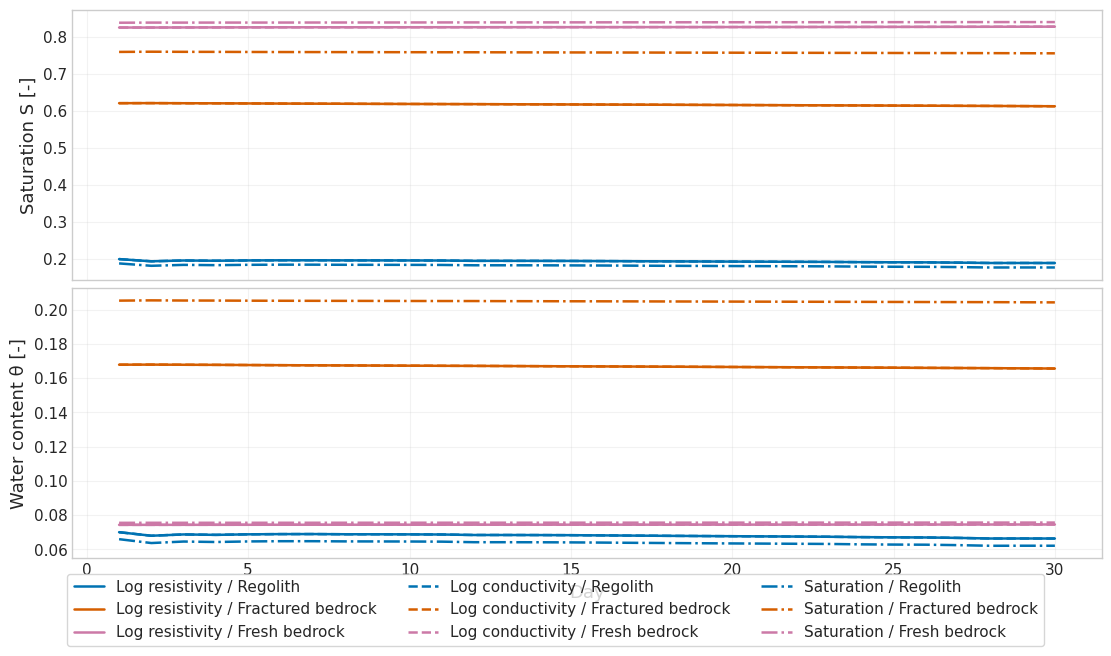

In [11]:
LAYER_NAMES = {1: 'Regolith', 2: 'Fractured bedrock', 3: 'Fresh bedrock'}
LAYER_COLORS = {1: '#0072B2', 2: '#D55E00', 3: '#CC79A7'}
LAYER_STYLES = {'log_resistivity': '-', 'log_conductivity': '--', 'saturation': '-.'}

baseline = case_models['log_resistivity']
class_ids = baseline['petro'].get('class')
if class_ids is None:
    print('No class model found; skip representative-point plot.')
else:
    centers = _mesh_cell_centers(baseline['nodes'], baseline['cells'])
    target_x = 0.45 * (np.nanmin(centers[:, 0]) + np.nanmax(centers[:, 0]))
    representative = {}
    for class_id in (1, 2, 3):
        mask = np.asarray(class_ids, dtype=int) == class_id
        if not np.any(mask):
            continue
        candidates = np.flatnonzero(mask)
        representative[class_id] = int(candidates[np.argmin(np.abs(centers[candidates, 0] - target_x))])
    print('Representative cells:', representative)

    fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True, constrained_layout=True)
    for row in summary_rows:
        data = case_models[row['case']]
        days = data['steps'].astype(float) / 24.0 + 1.0
        for class_id, cell_id in representative.items():
            suffix = f"{row['label']} / {LAYER_NAMES[class_id]}"
            axes[0].plot(
                days,
                data['saturation'][cell_id],
                color=LAYER_COLORS[class_id],
                ls=LAYER_STYLES[row['case']],
                lw=1.8,
                label=suffix,
            )
            axes[1].plot(
                days,
                data['water_content'][cell_id],
                color=LAYER_COLORS[class_id],
                ls=LAYER_STYLES[row['case']],
                lw=1.8,
                label=suffix,
            )
    axes[0].set_ylabel('Saturation S [-]')
    axes[1].set_ylabel('Water content θ [-]')
    axes[1].set_xlabel('Day')
    for ax in axes:
        ax.grid(alpha=0.25)
    handles, labels = axes[0].get_legend_handles_labels()
    # Put a compact legend below the figure to avoid covering time-series lines.
    fig.legend(handles, labels, loc='lower center', ncol=3, bbox_to_anchor=(0.5, -0.08), frameon=True)
    plt.show()


## Suggested Full Runs

如果快测结果显示 `saturation` 稳定，建议先跑全年饱和度反演：

```bash
uv run python examples/2_timelapsedERT_inversion_deepert.py   --petrophysical-transform saturation   --output-dir ../result/2_timelapsedERT_inversion_deepert_saturation
```

如果要做参数化对比，保持其他参数完全一致，只改：

```bash
--petrophysical-transform log_resistivity
--petrophysical-transform log_conductivity
--petrophysical-transform saturation
```
